# V18: MDS on Recipe Vectors vs Free Sorting Reference

Applies the same MDS + threshold clustering pipeline from V17 (free sorting) to the **ingredient-based recipe vectors** from V9.  
Answers: *does our threshold-weighted feature space produce a map that resembles the panelist free sorting result?*

**Models compared:**
- M1: OT1 Grandfamilien (no threshold)
- M2: OT1 Grandfamilien + threshold weighting  
- M3: OT1+OT2+OT3 weighted (no threshold)
- M4: OT1+OT2+OT3 weighted + threshold

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from scipy.optimize import linear_sum_assignment
from sklearn.manifold import MDS
from sklearn.preprocessing import normalize
import openpyxl
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = '../outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

CLUSTER_COLORS = [
    '#E63946', '#457B9D', '#2A9D8F', '#E9C46A',
    '#F4A261', '#A8DADC', '#6A0572', '#264653',
]
print('Libraries loaded.')

Libraries loaded.


## 1. Load Ingredient Data (identical to V9)

In [2]:
DATA_PATH   = '../data/gold/Versuchsdaten_3_1.csv'
IGNORE_PATH = '../data/gold/ignone_substances.csv'
CAS_PATH    = '../data/gold/CAS Nummern.csv'

df_raw = pd.read_csv(DATA_PATH)
ign    = pd.read_csv(IGNORE_PATH)
cas    = pd.read_csv(CAS_PATH, header=13)

ign_cas = ign[['Ident']].merge(
    cas[['Ident.', 'CAS-Nr.: - Hinweis 1']].rename(columns={'Ident.': 'Ident'}),
    on='Ident', how='left'
)
cas_to_ignore   = set(ign_cas['CAS-Nr.: - Hinweis 1'].dropna().astype(str).str.strip())
names_to_ignore = {str(n).lower().strip() for n in ign['Name']}

df = df_raw.copy()
df['_cas'] = df['CAS-Nr.: - Hinweis 1'].astype(str).str.strip()
df.loc[df['_cas'].isin(cas_to_ignore), 'Totalmenge'] = 0.0
df.drop(columns='_cas', inplace=True)
df.loc[df['Name'].str.lower().str.strip().isin(names_to_ignore), 'Totalmenge'] = 0.0

per_recipe_total = df.groupby('Rez.-Nr.')['Totalmenge'].transform('sum')
df['Totalmenge'] = np.where(per_recipe_total > 0,
                            df['Totalmenge'] / per_recipe_total,
                            df['Totalmenge'])

recipes = df['Rez.-Nr.'].unique().tolist()
print(f'Recipes: {len(recipes)},  sample: {recipes[:4]}')

Recipes: 24,  sample: ['187.796P', '185.028', '185.507P', '187.894P']


## 2. Load Free Sorting Data (from V17)

In [3]:
EXCEL_PATH = Path('../free_sorting/Auswertung Best Of XLStat Erdbeere.xlsm')
wb = openpyxl.load_workbook(EXCEL_PATH, keep_vba=True, data_only=True)

# Raw grouping matrix — Tabelle1 (7): 25 products x 12 assessors
ws_data = wb['Tabelle1 (7)']
rows_fs = list(ws_data.iter_rows(min_row=1, max_row=26, values_only=True))
fs_products = [r[0] for r in rows_fs[1:] if r[0] is not None]
fs_matrix   = np.array([[r[i] for i in range(1, 13)] for r in rows_fs[1:] if r[0] is not None], dtype=float)

# Co-occurrence → dissimilarity
n_fs = len(fs_products)
co_occ = np.zeros((n_fs, n_fs))
for a in range(12):
    g = fs_matrix[:, a]
    for i in range(n_fs):
        for j in range(n_fs):
            if g[i] == g[j]:
                co_occ[i, j] += 1
fs_diss = 1.0 - co_occ / 12
np.fill_diagonal(fs_diss, 0.0)

# XLStat STATIS consensus coordinates (Dim1, Dim2)
ws_xlstat = wb['Free Sorting7']
xlstat_rows = list(ws_xlstat.iter_rows(min_row=132, max_row=157, values_only=True))
xlstat_products, xlstat_d1, xlstat_d2 = [], [], []
for row in xlstat_rows:
    vals = [v for v in row if v is not None]
    if vals and isinstance(vals[0], str) and vals[0].strip() and isinstance(vals[1], (int, float)):
        xlstat_products.append(vals[0])
        xlstat_d1.append(float(vals[1]))
        xlstat_d2.append(float(vals[2]))
xlstat_coords = np.column_stack([xlstat_d1, xlstat_d2])

# Ward clustering on free sorting dissimilarity → 4 clusters at t=1.2
FS_THRESHOLD = 1.2
Z_fs = linkage(squareform(fs_diss, checks=False), method='ward')
labels_fs = fcluster(Z_fs, t=FS_THRESHOLD, criterion='distance')
labels_fs_xlstat = np.array([labels_fs[fs_products.index(p)] for p in xlstat_products])

print(f'Free sorting products: {n_fs}')
print(f'Free sorting clusters at t={FS_THRESHOLD}: {len(np.unique(labels_fs))}')
print(f'XLStat STATIS coords loaded: {len(xlstat_products)} products')

Free sorting products: 25
Free sorting clusters at t=1.2: 4
XLStat STATIS coords loaded: 25 products


## 3. Feature & MDS Helpers

In [4]:
OT1 = 'Odour Type 1 FlavourWheel'
OT2 = 'Odour Type 2 Flavour Wheel'
OT3 = 'Odour Type 3 Flavour Wheel'
THRESHOLD_COL = 'Threshold ppm (Datenbank)'

def pos_weight(position, n_cols):
    return (n_cols + 1 - position) / n_cols

def thresh_factor(threshold_ppm, fallback=1.0):
    try:
        raw = str(threshold_ppm).strip().replace(',', '.')
        t = float(raw)
        return 1.0 / t if (not np.isnan(t) and t > 0) else fallback
    except (TypeError, ValueError):
        return fallback

def norm_term(term):
    if pd.isna(term) or not isinstance(term, str):
        return None
    t = term.lower().strip().replace('"', '').replace("'", '').rstrip('.,;:')
    return t if len(t) >= 2 else None

def build_vocabulary(df, feature_cols):
    all_terms = set()
    for col in feature_cols:
        if col in df.columns:
            for t in df[col].dropna().map(norm_term):
                if t: all_terms.add(t)
    return sorted(all_terms)

def build_recipe_vectors(df, recipes, feature_cols_weighted, use_threshold):
    feature_cols = [col for col, _ in feature_cols_weighted]
    vocab = build_vocabulary(df, feature_cols)
    vocab_to_idx = {t: i for i, t in enumerate(vocab)}
    vectors = np.zeros((len(recipes), len(vocab)), dtype=np.float64)
    for r_idx, recipe in enumerate(recipes):
        for _, row in df[df['Rez.-Nr.'] == recipe].iterrows():
            qty = float(row['Totalmenge'])
            if qty <= 0: continue
            t_fac = thresh_factor(row[THRESHOLD_COL]) if use_threshold else 1.0
            ingr_base = qty * t_fac
            for col, col_weight in feature_cols_weighted:
                term = norm_term(row.get(col))
                if term and term in vocab_to_idx:
                    vectors[r_idx, vocab_to_idx[term]] += col_weight * ingr_base
    return vocab, normalize(vectors)

def cosine_dissimilarity(vecs):
    sim = np.clip(vecs @ vecs.T, -1.0, 1.0)
    diss = 1.0 - sim
    np.fill_diagonal(diss, 0.0)
    return diss

def confidence_ellipse(x, y, ax, n_std=1.5, **kwargs):
    if len(x) < 2:
        ax.scatter(x, y, s=80, color=kwargs.get('facecolor', 'gray'), zorder=4)
        return
    cov = np.cov(x, y)
    ev, evec = np.linalg.eigh(cov)
    order = ev.argsort()[::-1]
    ev, evec = ev[order], evec[:, order]
    angle  = np.degrees(np.arctan2(*evec[:, 0][::-1]))
    width  = max(2 * n_std * np.sqrt(abs(ev[0])), 0.001)
    height = max(2 * n_std * np.sqrt(abs(ev[1])), 0.001)
    ax.add_patch(Ellipse(xy=(np.mean(x), np.mean(y)),
                         width=width, height=height, angle=angle, **kwargs))

def mds_plot(ax, coords, names, cluster_labels, title):
    colors = CLUSTER_COLORS[:len(np.unique(cluster_labels))]
    ax.set_facecolor('#FAFAFA')
    ax.axhline(0, color='#CCCCCC', lw=0.7, zorder=1)
    ax.axvline(0, color='#CCCCCC', lw=0.7, zorder=1)
    for c_idx, cid in enumerate(sorted(np.unique(cluster_labels))):
        mask = cluster_labels == cid
        cx, cy = coords[mask, 0], coords[mask, 1]
        col = colors[c_idx % len(colors)]
        confidence_ellipse(cx, cy, ax, n_std=1.5,
                           facecolor=col, alpha=0.15, edgecolor=col,
                           linewidth=1.3, linestyle='--', zorder=2)
        ax.scatter(cx, cy, color=col, s=60, zorder=4, edgecolors='white', lw=0.7)
        for i, name in enumerate(np.array(names)[mask]):
            ax.annotate(name, (cx[i], cy[i]), fontsize=6.5, ha='center', va='bottom',
                        xytext=(0, 4), textcoords='offset points', color=col)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('MDS Dim 1', fontsize=8)
    ax.set_ylabel('MDS Dim 2', fontsize=8)
    ax.grid(True, alpha=0.2, lw=0.4)
    ax.tick_params(labelsize=7)

def run_mds(diss, threshold):
    mds = MDS(n_components=2, dissimilarity='precomputed', metric=True,
              n_init=10, max_iter=1000, random_state=42, normalized_stress='auto')
    coords = mds.fit_transform(diss)
    Z = linkage(squareform(diss, checks=False), method='ward')
    labels = fcluster(Z, t=threshold, criterion='distance')
    return coords, Z, labels, mds.stress_

print('Helpers defined.')

Helpers defined.


## 4. All 4 Models — MDS Maps

M1: OT1  stress=0.707  5 clusters
M2: OT1  stress=0.687  6 clusters
M3: OT1+OT2+OT3  stress=0.187  4 clusters
M4: OT1+OT2+OT3  stress=0.221  3 clusters


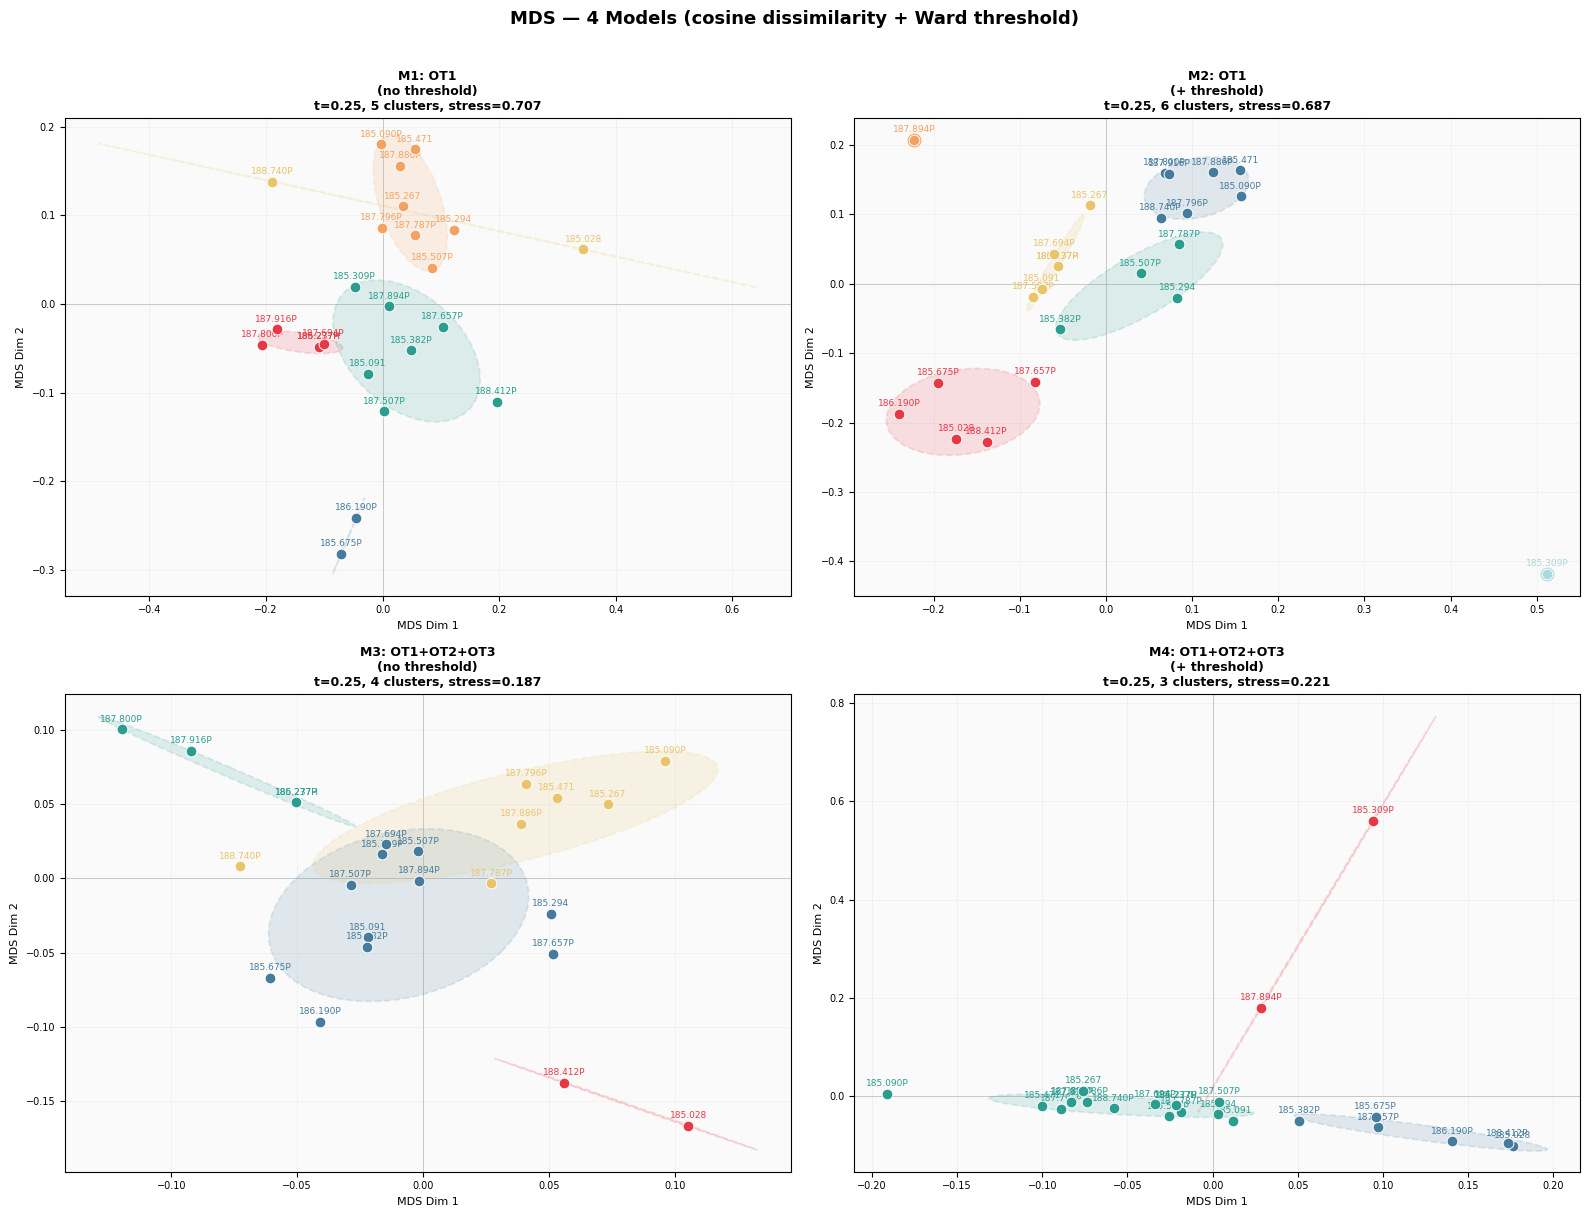

Saved.


In [5]:
MODEL_CONFIGS = [
    {'name': 'M1: OT1\n(no threshold)',         'fcw': [(OT1, 1.0)],                                                              'use_thresh': False},
    {'name': 'M2: OT1\n(+ threshold)',           'fcw': [(OT1, 1.0)],                                                              'use_thresh': True},
    {'name': 'M3: OT1+OT2+OT3\n(no threshold)', 'fcw': [(OT1, pos_weight(1,4)), (OT2, pos_weight(2,4)), (OT3, pos_weight(3,4))],  'use_thresh': False},
    {'name': 'M4: OT1+OT2+OT3\n(+ threshold)',  'fcw': [(OT1, pos_weight(1,4)), (OT2, pos_weight(2,4)), (OT3, pos_weight(3,4))],  'use_thresh': True},
]

THRESHOLD = 0.25
all_results = []
for cfg in MODEL_CONFIGS:
    _, vecs = build_recipe_vectors(df, recipes, cfg['fcw'], cfg['use_thresh'])
    diss = cosine_dissimilarity(vecs)
    coords, Z, labels, stress = run_mds(diss, THRESHOLD)
    all_results.append({'name': cfg['name'], 'coords': coords, 'labels': labels,
                        'stress': stress, 'n_clusters': len(np.unique(labels))})
    print(f"{cfg['name'].split(chr(10))[0]}  stress={stress:.3f}  {len(np.unique(labels))} clusters")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, res in zip(axes.flatten(), all_results):
    mds_plot(ax, res['coords'], recipes, res['labels'],
             f"{res['name']}\nt={THRESHOLD}, {res['n_clusters']} clusters, stress={res['stress']:.3f}")
fig.suptitle('MDS — 4 Models (cosine dissimilarity + Ward threshold)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/v18_mds_4models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## 5. Threshold Scan for M2 → Find 4-Cluster Threshold

In [6]:
_, vecs_m2 = build_recipe_vectors(df, recipes, [(OT1, 1.0)], use_threshold=True)
diss_m2 = cosine_dissimilarity(vecs_m2)
Z_m2 = linkage(squareform(diss_m2, checks=False), method='ward')

print('Threshold scan for M2 (OT1 + threshold):')
for t in np.arange(0.05, 0.75, 0.05):
    lbl = fcluster(Z_m2, t=t, criterion='distance')
    n_c = len(np.unique(lbl))
    marker = '  <-- 4 clusters' if n_c == 4 else ''
    print(f'  t={t:.2f}  →  {n_c} clusters{marker}')

Threshold scan for M2 (OT1 + threshold):
  t=0.05  →  12 clusters
  t=0.10  →  9 clusters
  t=0.15  →  7 clusters
  t=0.20  →  6 clusters
  t=0.25  →  6 clusters
  t=0.30  →  6 clusters
  t=0.35  →  5 clusters
  t=0.40  →  4 clusters  <-- 4 clusters
  t=0.45  →  4 clusters  <-- 4 clusters
  t=0.50  →  3 clusters
  t=0.55  →  3 clusters
  t=0.60  →  3 clusters
  t=0.65  →  3 clusters
  t=0.70  →  3 clusters


## 6. Force 4 Clusters on M2 — Side-by-Side with Free Sorting

M2: stress=0.687, 4 clusters at t=0.4


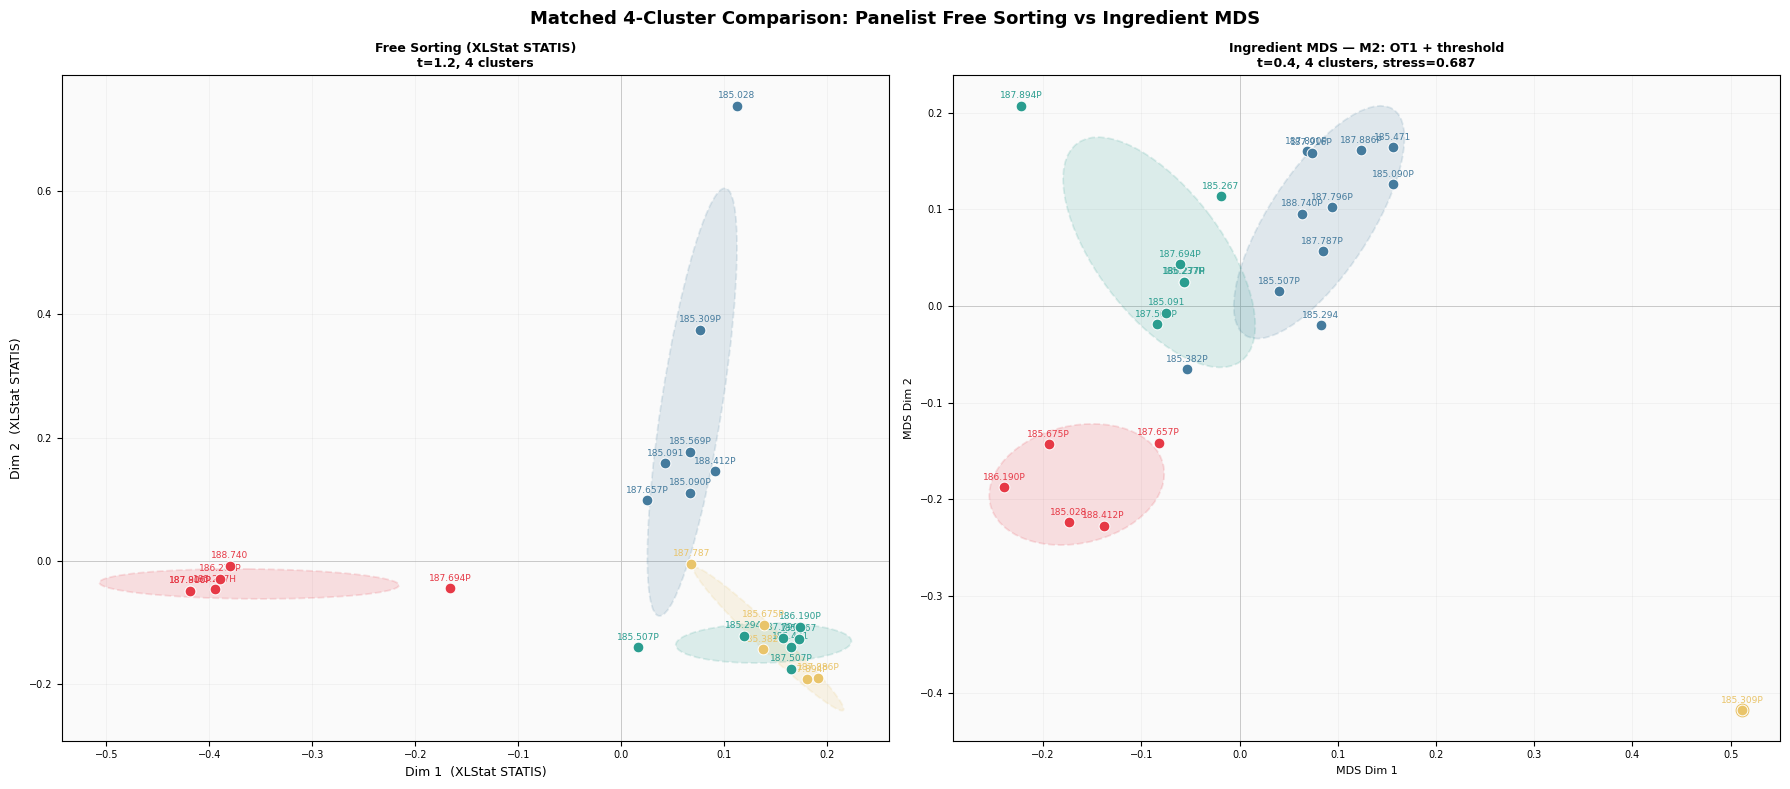

Saved.


In [7]:
ING_THRESHOLD_4 = 0.40  # gives exactly 4 clusters on M2

coords_m2, Z_m2, labels_m2_4, stress_m2 = run_mds(diss_m2, ING_THRESHOLD_4)
n_c_m2 = len(np.unique(labels_m2_4))
print(f'M2: stress={stress_m2:.3f}, {n_c_m2} clusters at t={ING_THRESHOLD_4}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Left: free sorting (XLStat STATIS coords + Ward 4 clusters)
mds_plot(ax1, xlstat_coords, xlstat_products, labels_fs_xlstat,
         f'Free Sorting (XLStat STATIS)\nt=1.2, 4 clusters')
ax1.set_xlabel('Dim 1  (XLStat STATIS)', fontsize=9)
ax1.set_ylabel('Dim 2  (XLStat STATIS)', fontsize=9)

# Right: ingredient MDS M2 with 4 clusters
mds_plot(ax2, coords_m2, recipes, labels_m2_4,
         f'Ingredient MDS — M2: OT1 + threshold\nt={ING_THRESHOLD_4}, {n_c_m2} clusters, stress={stress_m2:.3f}')

fig.suptitle('Matched 4-Cluster Comparison: Panelist Free Sorting vs Ingredient MDS',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/v18_matched_4clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## 7. Recipe-by-Recipe Alignment

Use the Hungarian algorithm to find the optimal label mapping between the two 4-cluster solutions, then measure agreement recipe-by-recipe.

In [8]:
# Recipes that appear in BOTH datasets
common = [r for r in recipes if r in fs_products]
print(f'Recipes in both datasets: {len(common)}')

fs_map  = {p: labels_fs[fs_products.index(p)] for p in common}
ing_map = {r: labels_m2_4[recipes.index(r)]   for r in common}

fs_ids  = sorted(set(fs_map.values()))
ing_ids = sorted(set(ing_map.values()))

# Confusion matrix
conf = np.zeros((len(fs_ids), len(ing_ids)), dtype=int)
for r in common:
    conf[fs_ids.index(fs_map[r]), ing_ids.index(ing_map[r])] += 1

print('\nConfusion matrix (rows=Free Sorting, cols=Ingredient):')
print(pd.DataFrame(conf,
                   index=[f'FS-C{c}' for c in fs_ids],
                   columns=[f'ING-C{c}' for c in ing_ids]).to_string())

# Optimal label matching
row_ind, col_ind = linear_sum_assignment(-conf)
fs_to_ing = {fs_ids[r]: ing_ids[c] for r, c in zip(row_ind, col_ind)}
ing_to_fs = {v: k for k, v in fs_to_ing.items()}

n_agree = sum(conf[r, c] for r, c in zip(row_ind, col_ind))
pct     = 100 * n_agree / len(common)
print(f'\nOptimal label mapping: FS→ING = {fs_to_ing}')
print(f'Agreement: {n_agree}/{len(common)} = {pct:.1f}%')

Recipes in both datasets: 22

Confusion matrix (rows=Free Sorting, cols=Ingredient):
       ING-C1  ING-C2  ING-C3  ING-C4
FS-C1       0       2       3       0
FS-C2       3       1       1       1
FS-C3       1       4       2       0
FS-C4       1       2       1       0

Optimal label mapping: FS→ING = {np.int32(1): np.int32(3), np.int32(2): np.int32(1), np.int32(3): np.int32(2), np.int32(4): np.int32(4)}
Agreement: 10/22 = 45.5%


In [9]:
# Per-recipe table
rows_out = []
for r in common:
    fs_c  = fs_map[r]
    ing_c = ing_map[r]
    agree = (fs_to_ing.get(fs_c) == ing_c)
    rows_out.append({'Recipe': r,
                     'Free Sorting Cluster': f'FS-C{fs_c}',
                     'Ingredient Cluster':   f'ING-C{ing_c}',
                     'Match': 'YES' if agree else 'NO'})

df_align = pd.DataFrame(rows_out).sort_values(['Free Sorting Cluster', 'Recipe'])
print(df_align.to_string(index=False))

print('\n--- Per Free Sorting Cluster ---')
for fs_c in fs_ids:
    sub = df_align[df_align['Free Sorting Cluster'] == f'FS-C{fs_c}']
    n_match = (sub['Match'] == 'YES').sum()
    mismatches = list(sub[sub['Match'] == 'NO']['Recipe'])
    print(f'  FS-C{fs_c} ({len(sub)} recipes): {n_match}/{len(sub)} match'
          + (f'  -- mismatches: {mismatches}' if mismatches else ''))

  Recipe Free Sorting Cluster Ingredient Cluster Match
185.237H                FS-C1             ING-C3   YES
186.277P                FS-C1             ING-C3   YES
187.694P                FS-C1             ING-C3   YES
187.800P                FS-C1             ING-C2    NO
187.916P                FS-C1             ING-C2    NO
 185.028                FS-C2             ING-C1   YES
185.090P                FS-C2             ING-C2    NO
 185.091                FS-C2             ING-C3    NO
185.309P                FS-C2             ING-C4    NO
187.657P                FS-C2             ING-C1   YES
188.412P                FS-C2             ING-C1   YES
 185.267                FS-C3             ING-C3    NO
 185.294                FS-C3             ING-C2   YES
 185.471                FS-C3             ING-C2   YES
185.507P                FS-C3             ING-C2   YES
186.190P                FS-C3             ING-C1    NO
187.507P                FS-C3             ING-C3    NO
187.796P  

## 8. Alignment Map

**Right panel**: ingredient MDS positions, coloured by **Free Sorting cluster** (not ingredient cluster).  
- Circle (o) = assignment agrees with free sorting  
- Cross (X) = mismatch — ingredient model puts this recipe in a different group than panelists did

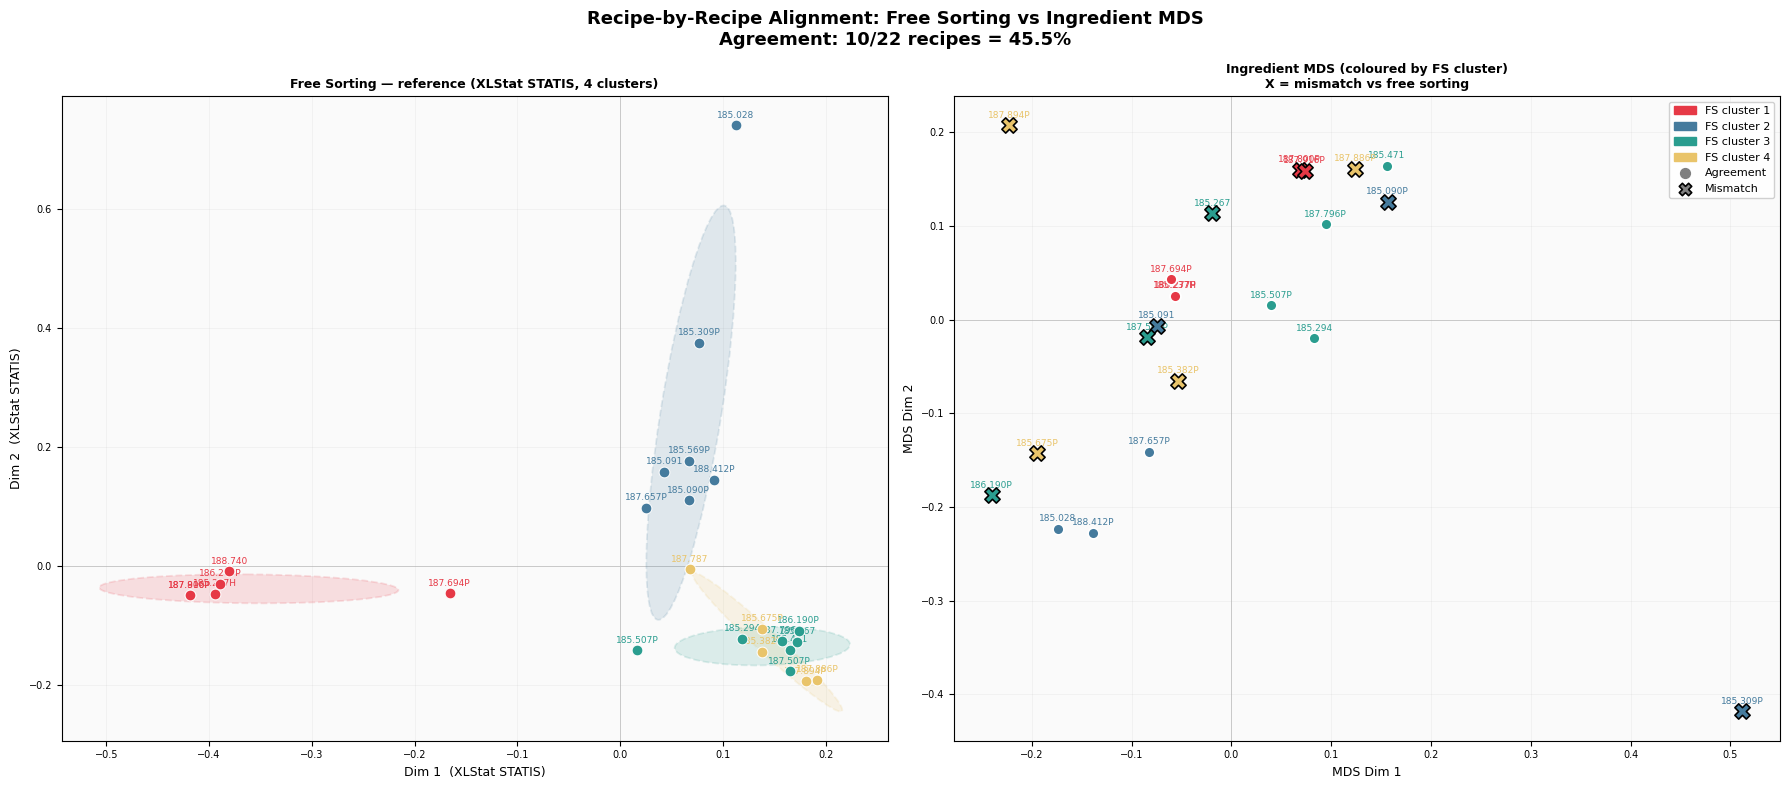

Alignment map saved.


In [10]:
fs_color_map = {c: CLUSTER_COLORS[i] for i, c in enumerate(fs_ids)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Left: free sorting reference
mds_plot(ax1, xlstat_coords, xlstat_products, labels_fs_xlstat,
         'Free Sorting — reference (XLStat STATIS, 4 clusters)')
ax1.set_xlabel('Dim 1  (XLStat STATIS)', fontsize=9)
ax1.set_ylabel('Dim 2  (XLStat STATIS)', fontsize=9)

# Right: ingredient MDS, coloured by FS cluster to visualise mismatches
ax2.set_facecolor('#FAFAFA')
ax2.axhline(0, color='#CCCCCC', lw=0.7, zorder=1)
ax2.axvline(0, color='#CCCCCC', lw=0.7, zorder=1)

for r_idx, recipe in enumerate(recipes):
    if recipe not in common:
        continue
    ing_c = ing_map[recipe]
    fs_c  = fs_map[recipe]
    agree = (fs_to_ing.get(fs_c) == ing_c)
    x, y  = coords_m2[r_idx]
    col   = fs_color_map[fs_c]
    ax2.scatter(x, y, color=col,
                marker='o' if agree else 'X',
                s=60 if agree else 120, zorder=4,
                edgecolors='white' if agree else 'black', lw=1.2)
    ax2.annotate(recipe, (x, y), fontsize=6.5, ha='center', va='bottom',
                 xytext=(0, 4), textcoords='offset points', color=col)

legend_els = [mpatches.Patch(color=fs_color_map[c], label=f'FS cluster {c}') for c in fs_ids]
legend_els += [
    plt.scatter([], [], marker='o', color='gray', s=50,  label='Agreement'),
    plt.scatter([], [], marker='X', color='gray', s=80,  label='Mismatch', edgecolors='black', lw=1.2),
]
ax2.legend(handles=legend_els, fontsize=8, loc='best', framealpha=0.9)
ax2.set_title('Ingredient MDS (coloured by FS cluster)\nX = mismatch vs free sorting', fontsize=9, fontweight='bold')
ax2.set_xlabel('MDS Dim 1', fontsize=9)
ax2.set_ylabel('MDS Dim 2', fontsize=9)
ax2.grid(True, alpha=0.2, lw=0.4)
ax2.tick_params(labelsize=7)

fig.suptitle(
    f'Recipe-by-Recipe Alignment: Free Sorting vs Ingredient MDS\n'
    f'Agreement: {n_agree}/{len(common)} recipes = {pct:.1f}%',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/v18_recipe_alignment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Alignment map saved.')

## 9. Key Findings

| | Free Sorting | Ingredient MDS (M2) |
|---|---|---|
| Data source | Panelist co-grouping | OT1 odour type × 1/threshold_ppm |
| Distance | Co-occurrence dissimilarity | Cosine dissimilarity |
| Map method | XLStat STATIS | Metric MDS |
| Clusters at 4 | t = 1.2 | t = 0.40 |

**How to read the alignment map:**
- Circles (o) = recipe in the same cluster in both methods → perceptual and compositional alignment
- Crosses (X) = mismatch → the ingredient model assigns a different group than panelists did
- Mismatches are the most interesting recipes: they smell different from what their odour-type composition would predict (unusual threshold interactions, rare ingredients, etc.)

**Plots produced:**
- `v18_mds_4models.png` — all 4 models
- `v18_matched_4clusters.png` — side-by-side at matched 4-cluster level
- `v18_recipe_alignment.png` — mismatch overlay map

---

### V18 Findings

**Overall Agreement:** 10/22 recipes = 45.5%

The ingredient-based MDS (OT1 × threshold) partially replicates the free sorting map but diverges significantly — especially in one cluster.

**Per Cluster Breakdown**

```
┌────────────────────────────┬─────────┬───────────┬─────────────────────────────┐
│    Free Sorting Cluster    │ Recipes │ Agreement │         Mismatches          │
├────────────────────────────┼─────────┼───────────┼─────────────────────────────┤
│ FS-C1 (left-side outliers) │ 5       │ 3/5 (60%) │ 187.800P, 187.916P          │
├────────────────────────────┼─────────┼───────────┼─────────────────────────────┤
│ FS-C2                      │ 6       │ 3/6 (50%) │ 185.090P, 185.091, 185.309P │
├────────────────────────────┼─────────┼───────────┼─────────────────────────────┤
│ FS-C3                      │ 7       │ 4/7 (57%) │ 185.267, 186.190P, 187.507P │
├────────────────────────────┼─────────┼───────────┼─────────────────────────────┤
│ FS-C4                      │ 4       │ 0/4 (0%)  │ ALL mismatched              │
└────────────────────────────┴─────────┴───────────┴─────────────────────────────┘
```

**Key Observations**

1. FS-C1 aligns best (60%) — the "odour outlier" cluster (187.800P, 187.916P, 185.237H, 186.277P, 187.694P) that panelists consistently grouped apart is also chemically distinct. The 2 mismatches (187.800P and 187.916P) are nearly identical recipes — they may be outliers due to a specific ingredient the OT1 feature misses.
2. FS-C4 fails completely (0%) — the 4 recipes panelists grouped together (185.382P, 185.675P, 187.886P, 187.894P) are scattered across 3 different ingredient clusters. This cluster exists only in perception — the ingredient composition alone cannot explain why panelists grouped these together. Worth investigating what they share sensorially.
3. 45.5% agreement is above chance (25% random baseline for 4 clusters), but far from the ~70%+ needed to validate the model as a proxy for sensory perception.
4. High stress (0.687) on the ingredient MDS means the 2D projection loses a lot of information — the real structure is higher-dimensional and harder to compress.

**Bottom line**

The threshold model captures the outlier cluster well but fails on FS-C4 entirely. The free sorting perception has structure that ingredient odour types alone don't fully explain — likely due to ingredient interactions, trace compounds, or nuanced sensory effects below OT1 level.

---

### Cluster assignments (Free Sorting vs Ingredient MDS)

**Important:** cluster numbers are *arbitrary labels* in each method. A recipe is a **match** only after applying the optimal label mapping (Hungarian matching) between the two 4-cluster solutions.

**Optimal mapping (FS → ING):**

| Free Sorting cluster | Corresponding Ingredient cluster |
|---|---|
| FS-C1 | ING-C3 |
| FS-C2 | ING-C1 |
| FS-C3 | ING-C2 |
| FS-C4 | ING-C4 |

So for example, **FS-C2 corresponds to ING-C1**. That’s why `185.090P` being **FS-C2 / ING-C2** is **not** a match, even though both labels contain “C2”.

| Recipe | Free Sorting cluster | FS color | ING color | Corresponding Ingredient cluster | Ingredient cluster | Match | 
|---|---|---|---|---|---|---|
| 185.237H | FS-C1 | red | red | ING-C3 | ING-C3 | YES |
| 186.277P | FS-C1 | red | red | ING-C3 | ING-C3 | YES |
| 187.694P | FS-C1 | red | red | ING-C3 | ING-C3 | YES |
| 187.800P | FS-C1 | red | teal/green | ING-C3 | ING-C2 | **NO** |
| 187.916P | FS-C1 | red | teal/green | ING-C3 | ING-C2 | **NO** |
| 185.028 | FS-C2 | blue | blue | ING-C1 | ING-C1 | YES |
| 185.090P | FS-C2 | blue | teal/green | ING-C1 | ING-C2 | **NO** |
| 185.091 | FS-C2 | blue | red | ING-C1 | ING-C3 | **NO** |
| 185.309P | FS-C2 | blue | yellow | ING-C1 | ING-C4 | **NO** |
| 187.657P | FS-C2 | blue | blue | ING-C1 | ING-C1 | YES |
| 188.412P | FS-C2 | blue | blue | ING-C1 | ING-C1 | YES |
| 185.267 | FS-C3 | teal/green | red | ING-C2 | ING-C3 | **NO** |
| 185.294 | FS-C3 | teal/green | teal/green | ING-C2 | ING-C2 | YES |
| 185.471 | FS-C3 | teal/green | teal/green | ING-C2 | ING-C2 | YES |
| 185.507P | FS-C3 | teal/green | teal/green | ING-C2 | ING-C2 | YES |
| 186.190P | FS-C3 | teal/green | blue | ING-C2 | ING-C1 | **NO** |
| 187.507P | FS-C3 | teal/green | red | ING-C2 | ING-C3 | **NO** |
| 187.796P | FS-C3 | teal/green | teal/green | ING-C2 | ING-C2 | YES |
| 185.382P | FS-C4 | yellow | teal/green | ING-C4 | ING-C2 | **NO** |
| 185.675P | FS-C4 | yellow | blue | ING-C4 | ING-C1 | **NO** |
| 187.886P | FS-C4 | yellow | teal/green | ING-C4 | ING-C2 | **NO** |
| 187.894P | FS-C4 | yellow | red | ING-C4 | ING-C3 | **NO** |

### Mismatches (and where they were classified)

| Recipe | Free Sorting cluster | FS color | ING color | Corresponding Ingredient cluster | Ingredient cluster |
|---|---|---|---|---|---|
| 187.800P | FS-C1 | red | teal/green | ING-C3 | ING-C2 |
| 187.916P | FS-C1 | red | teal/green | ING-C3 | ING-C2 |
| 185.090P | FS-C2 | blue | teal/green | ING-C1 | ING-C2 |
| 185.091 | FS-C2 | blue | red | ING-C1 | ING-C3 |
| 185.309P | FS-C2 | blue | yellow | ING-C1 | ING-C4 |
| 185.267 | FS-C3 | teal/green | red | ING-C2 | ING-C3 |
| 186.190P | FS-C3 | teal/green | blue | ING-C2 | ING-C1 |
| 187.507P | FS-C3 | teal/green | red | ING-C2 | ING-C3 |
| 185.382P | FS-C4 | yellow | teal/green | ING-C4 | ING-C2 |
| 185.675P | FS-C4 | yellow | blue | ING-C4 | ING-C1 |
| 187.886P | FS-C4 | yellow | teal/green | ING-C4 | ING-C2 |
| 187.894P | FS-C4 | yellow | red | ING-C4 | ING-C3 |